# Alignment and Reasoning

In this assignment, you will gain some hands-on experience with training language models to reason when solving math problems.

**What you will implement:**
1. Zero-shot prompting baseline for the MATH dataset of competition math problems *Hendrycks et al. (2021)*.
2. Supervised finetuning, given reasoning traces from a stronger reasoning model (*DeepSeek R1, DeepSeekAI et al. 2025*).
3. Expert Iteration for improving reasoning performance with verified rewards.
4. Group-Relative Policy Optimization (GRPO) for improving reasoning performance with verified rewards.

**What you will run:**
1. Measure Qwen 2.5 Math 1.5B zero-shot prompting performance (our baseline).
2. Run SFT on Qwen 2.5 Math 1.5B with reasoning traces from R1.
3. Run Expert Iteration on Qwen 2.5 Math 1.5B with verified rewards.
4. Run GRPO on Qwen 2.5 Math 1.5B with verified rewards.

**What you can use:** We expect you to build most of the RL related components from scratch. You may use tools like vLLM to generate text from language models. In addition, you may use *HuggingFace Transformers* to load the Qwen 2.5 Math 1.5B model and tokenizer and run forward passes, but you should not use any of the training utilities (e.g. the `Trainer` class).

In [ ]:
import torch
from torch import Tensor
from torch.utils.data import Dataset
from transformers import PreTrainedTokenizerBase

import sys; sys.path.insert(0, '..')
from tests.test_alignment import *

In [ ]:
seed = 42
torch.manual_seed(seed)

In [ ]:
def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

device = get_device()
print(f'device = {device}')

## Reasoning with Language Models

### Motivation

One of the remarkable use cases of language models is in building generalist systems that can handle a wide range of natural language processing tasks. In this assignment, we will focus on a developing use case for language models: mathematical reasoning. It will serve as a testbed for us to set up evaluations, perform supervised finetuning, and experiment with teaching LMs to reason using reinforcement learning (RL).

There are going to be two differences from the way we’ve done our past assignments.
1. We are not going to be using our language model codebase and models from earlier. We would ideally like to use base language models trained from previous assignments, but finetuning those models will not give us a satisfying result—these models are far too weak to display non-trivial mathematical reasoning capabilities. Because of this, we are going to switch to a modern, high-performance language model that we can access (Qwen 2.5 Math 1.5B Base) and do most of our work on top of that model.
2. We are going to introduce a new benchmark with which to evaluate our language models. Up until this point, we have embraced the view that cross-entropy is a good surrogate for many downstream tasks. However, the point of this assignment will be to bridge the gap between base models and downstream tasks and so we will have to use evaluations that are separate from cross-entropy. We will use the MATH 12K dataset from *Hendrycks et al. (2021)*, which consists of challenging high-school competition mathematics problems. We will evaluate language model outputs by comparing them against a reference answer.

### Chain-of-Thought Reasoning and Reasoning RL

An exciting recent trend in language models is the use of *chain-of-thought* reasoning to improve performance across a variety of tasks. Chain-of-thought refers to the process of reasoning through a problem step-by-step, generating intermediate reasoning steps before arriving at a final answer.

**Chain-of-thought reasoning with LLMs:** Early chain-of-thought approaches finetuned language models to solve simple mathematical tasks like arithmetic by using a “scratchpad” to break the problem into intermediate steps (*Nye et al., 2021*). Other work prompts a strong model to “think step by step” before answering, finding that this significantly improves performance on mathematical reasoning tasks like grade-school math questions (*Wei et al., 2023*).

**Learning to reason with expert iteration:** The Self-Taught Reasoner (STaR) (*Zelikman et al., 2022*) frames reasoning as a bootstrapping loop: a pretrained model first samples diverse chains-of-thought (CoTs), keeps only those that lead to correct answers, and then finetunes on these “expert” traces. Iterating this cycle can improve the LM’s reasoning capabilities and solve rate. STaR demonstrated that this version of expert iteration (*Anthony et al., 2017*) using automatic, string match–based verification of generated answers can bootstrap reasoning skills without human-written reasoning traces.

**Reasoning RL with verified rewards**: Recent work has explored using more powerful reinforcement learning algorithms with verified rewards to improve reasoning performance. OpenAI’s o1 (and subsequent o3/o4) (*OpenAI et al., 2024*), DeepSeek’s R1 (*DeepSeek-AI et al., 2025*), and Moonshot’s kimi k1.5 (*Team et al., 2025*) use policy gradient methods (*Sutton et al., 1999*) to train on math and code tasks where string matching or unit tests verify correctness, demonstrating remarkable improvements in competition math and coding performance. Later works such as Open-R1 (*Face, 2025*), SimpleRL-Zoo (*Zeng et al., 2025*), and TinyZero (*Pan et al., 2025*) confirm that pure reinforcement learning with verified rewards—even on models as small as 1.5B parameters—can improve reasoning performance.

**Our setup: model and dataset:** In the following sections, we will consider progressively more complex approaches to train a base language model to reason step-by-step in order to solve math problems. For this assignment, we will be using the Qwen 2.5 Math 1.5B Base model, which was continually pretrained from the Qwen 2.5 1.5B model on high-quality synthetic math pretraining data (*Yang et al., 2024*). The dataset is available on the Together cluster at `/data/a5-alignment/MATH`.

**Tip for Open-Source Auditors: Alternative Datasets:**

If you are interested in using datasets other than the MATH dataset for whatever reason, you may also consider using one of these other open-source mathematical reasoning datasets:
- Countdown (*Pan et al., 2025*), available here: a simple synthetic task based on the British TV
show Countdown that has served as a popular testbed for small-scale reasoning RL.
- GSM8K (*Cobbe et al., 2021a*), available here: grade-school math problems, which are easier than
MATH but should allow you to debug correctness and get familiar with the reasoning RL pipeline.
- Tulu 3 SFT Math (*Lambert et al., 2025*), available here: synthetic math problems generated
using GPT-4o and Claude 3.5 Sonnet. Because these are synthetic, some answers (or even the
questions) may not be entirely correct.
- Some other math SFT dataset linked here.

To obtain short ground-truth labels (e.g., 1/2) if they are not provided directly, you can process the ground-truth column with a math answer parser such as Math-Verify.

## Measuring Zero-Shot MATH Performance

We’ll start by measuring the performance of our base language model on the 5K example test set of MATH. Establishing this baseline is useful for understanding how each of the later approaches affects model behavior.

Unless otherwise specified, for experiments on MATH we will use the following prompt from the DeepSeek R1-Zero model (*DeepSeek-AI et al., 2025*). We will refer to this as the `r1_zero` prompt:

```
A conversation between User and Assistant. The User asks a question, and the Assistant solves it. The Assistant first thinks about the reasoning process in the mind and then provides the User with the answer. The reasoning process is enclosed within <think> </think> and answer is enclosed within <answer> </answer> tags, respectively, i.e., <think> reasoning process here </think> <answer> answer here </answer>.
User: {question}
Assistant: <think>
```

The `r1_zero` prompt is located in the text file `cs336_alignment/prompts/r1_zero.prompt`. In the prompt, question refers to some question that we insert, for example: `Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?`

The expectation is that the model plays the role of the assistant, and starts generating the thinking process (since we have already included a left think tag `<think>`), closes the thinking process with `</think>` and then generates a final symbolic answer within the answer tags, like `<answer> 4x + 10 </answer>`. The purpose of having the model generate tags like `<answer> </answer>` is so that we can easily parse the model’s output and compare it against a ground truth answer, and so that we can stop response generation when we see the right answer tag `</answer>`.

*Note on prompt choice:* It turns out that the `r1_zero` prompt is not the best choice for maximizing downstream performance after RL, because of a mismatch between the prompt and how the Qwen 2.5 Math 1.5B model was pretrained. *Liu et al. (2025)* finds that simply prompting the model with the question (and nothing else) starts with a very high accuracy, e.g. matching the `r1_zero` prompt after 100+ steps of RL. Their findings suggest that Qwen 2.5 Math 1.5B was already pretrained on such question-answer pairs. Nonetheless, we choose the `r1_zero` prompt for this assignment because RL with it shows clear accuracy improvements in a short number of steps, allowing us to walk through the mechanics of RL and sanity check correctness quickly, even if we don’t manage the best final performance. As a reality check, you will compare directly to the question_only prompt later in the assignment.

### Using vLLM for offline language model inference

To evaluate our language models, we’re going to have to generate continuations (responses) for a variety of prompts. While one could certainly implement their own functions for generation (e.g., as you did in the first assignment), efficient implementation of RL requires high performance inference techniques, and implementing these inference techniques are beyond the scope of this assignment. Therefore, in this assignment we will recommend using vLLM for offline batched inference. vLLM is a high-throughput and memory-efficient inference engine for language models that incorporates a variety of useful efficiency techniques (e.g., optimized CUDA kernels, PagedAttention for efficient attention KV caching (*Kwon et al., 2023*), etc.). To use vLLM to generate continuations for a list of prompts use the following code, taken from [here](https://github.com/vllm-project/vllm/blob/main/examples/offline_inference.py):

```python
from vllm import LLM, SamplingParams
# Sample prompts.
prompts = ['Hello, my name is', 'The president of the United States is', 
           'The capital of France is', 'The future of AI is']
# Create a sampling params object, stopping generation on newline.
sampling_params = SamplingParams(temperature=1.0, top_p=1.0, max_tokens=1024, stop=["\n"])
# Create an LLM.
llm = LLM(model=<path to model>)
# Generate texts from the prompts. The output is a list of RequestOutput objects
# that contain the prompt, generated text, and other information.
outputs = llm.generate(prompts, sampling_params)
# Print the outputs.
for output in outputs:
    prompt = output.prompt
    generated_text = output.outputs[0].text
    print(f'Prompt: {prompt!r}, Generated text: {generated_text!r}')
```

In the example above, the LLM can be initialized with the name of a HuggingFace model (which will be automatically downloaded and cached if it isn’t found locally), or a path to a HuggingFace model. Since downloads can take a long time (especially for larger models, e.g., 70B parameters) and to conserve cluster disk space (so everyone doesn’t have their own independent copy of the pre-trained models), we have
downloaded the following pre-trained models at the following the paths on the Together cluster. Please do not re-download these models on the Together cluster:
- Qwen 2.5 Math 1.5B Base (for reasoning experiments): `/data/a5-alignment/models/Qwen2.5-Math-1.5B`
- Llama 3.1 8B Base (for optional instruction tuning experiments): `/data/a5-alignment/models/Llama-3.1-8B`
- Llama 3.3 70B Instruct (for optional instruction tuning experiments): `/data/a5-alignment/models/Llama-3.3-70B-Instruct`

### Zero-shot MATH Baseline

**Prompting setup:** To evaluate zero-shot performance on the MATH test set, we’ll simply load the examples and prompt the language model to answer the question using the `r1_zero` prompt from above.

**Evaluation metric:** When we evaluate a multiple-choice or binary response task, the evaluation metric is clear—we test whether the model outputs exactly the correct answer. In math problems we assume that there is a known ground truth (e.g. `0.5`) but we cannot simply test whether the model outputs exactly `0.5`—it can also answer `<answer> 1/2 </answer>`. Because of this, we must address the tricky problem of matching for semantically equivalent responses from the LM when we evaluate MATH.

To this end, we want to come up with some answer parsing function that takes as input the model’s output and a known ground-truth, and returns a boolean indicating whether the model’s output is correct. For example, a reward function could receive the model’s string output ending in `<answer> She sold 15 clips. </answer>` and the gold answer `72`, and return `True` if the model’s output is correct and `False` otherwise (in this case, it should return `False`).

For our MATH experiments, we will use a fast and fairly accurate answer parser used in recent work on reasoning RL (*Liu et al., 2025*). This reward function is implemented at `cs336_alignment.drgrpo_grader.r1_zero_reward_fn`, and you should use it to evaluate performance on MATH unless otherwise specified.

**Generation hyperparameters:** When generating responses, we’ll sample with temperature `1.0`, top-p `1.0`, max generation length `1024`. The prompt asks the model to end its answer with the string `</answer>`, and therefore we can direct vLLM to stop when the model outputs this string:

```python
# Based on Dr. GRPO: stop when the model completes its answer
# https://github.com/sail-sg/understand-r1-zero/blob/c18804602b85da9e88b4aeeb6c43e2f08c594fbc/train_zero_math.py#L167
sampling_params.stop = ["</answer>"]
sampling_params.include_stop_str_in_output = True
```

#### Problem: MATH Baseline

First, write a script to evaluate Qwen 2.5 Math 1.5B zero-shot performance on MATH. This script should:
    - load the MATH validation examples from `/data/a5-alignment/MATH/validation.jsonl`,
    - format them as string prompts to the language model using the `r1_zero` prompt,
    - generate outputs for each example,
    - calculate evaluation metrics, and
    - serialize the examples, model generations, and corresponding evaluation scores to disk for analysis in subsequent problems.

It might be helpful for your implementation to include a method `evaluate_vllm` with arguments similar to the following, as you will be able to reuse it later:

```python
def evaluate_vllm(vllm_model, reward_fn, prompts, eval_sampling_params):
    """
    Evaluate a language model on a list of prompts,
    compute evaluation metrics, and serialize results to disk.
    """
```

Provide a script to evaluate baseline zero-shot MATH performance.


Next, run your evaluation script on Qwen 2.5 Math 1.5B. How many model generations fall into each of the following categories: (1) correct with both format and answer reward 1, (2) format reward 1 and answer reward 0, (3) format reward 0 and answer reward 0? Observing at least 10 cases where format reward is 0, do you think the issue is with the base model’s output, or the parser? Why? What about in (at least 10) cases where format reward is 1 but answer reward is 0? Comment on the model and reward function performance, including examples of each category.

Finally, comment on how well the Qwen 2.5 Math 1.5B zero-shot baseline performs on MATH. Give 1-2 sentences with evaluation metrics.

## Supervised Finetuning for MATH

<center>
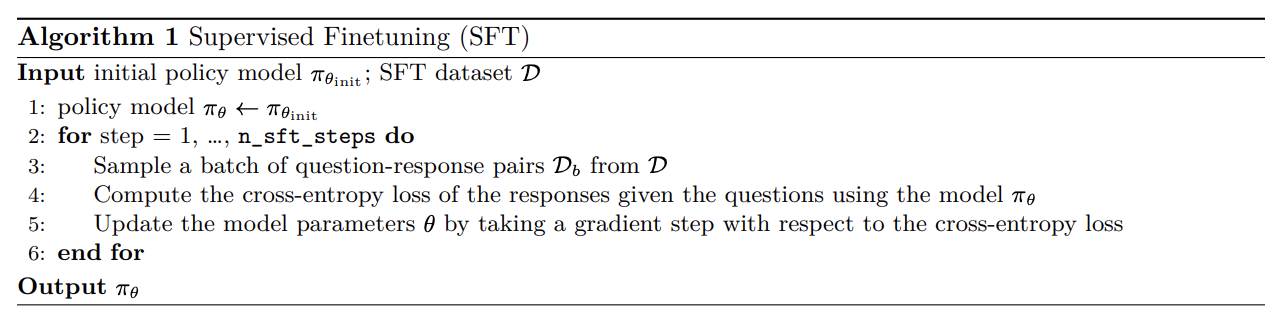
</center>

**Supervised finetuning for reasoning:** In this section, we will finetune our base model on the MATH dataset (*Algorithm 1*). As our goal is to improve the model’s reasoning ability, rather than finetune it to directly predict correct answers, we will finetune it to first generate a chain-of-thought reasoning trace followed by an answer. To this end, we have made available a dataset `/data/a5-alignment/MATH/sft.jsonl` of such reasoning traces, obtained from DeepSeek R1 *DeepSeek-AI et al. (2025)*.

When training a reasoning model in practice, SFT is often used as a warm-start for a second RL finetuning step. There are two main reasons for this. First, SFT requires high-quality annotated data (i.e., with pre-existing reasoning traces), whereas RL requires only the correct answer for feedback. Second, even in settings where annotated data is plentiful, RL can still unlock performance gains by finding better policies than the SFT data. Unfortunately, the models we use are not big enough to show effects when composing SFT and RL, so for this assignment we will treat these two phases separately.

### Using HuggingFace Models

*Loading a HuggingFace model and tokenizer:* To load a HuggingFace model and tokenizer from a local dir (in `bfloat16` and with FlashAttention-2 to save memory), you can use the following starter code:

```python
from transformers import AutoModelForCausalLM, AutoTokenizer
model = AutoModelForCausalLM.from_pretrained('/data/a5-alignment/models/Qwen2.5-Math-1.5B', torch_dtype=torch.bfloat16,
                                             attn_implementation='flash_attention_2')
tokenizer = AutoTokenizer.from_pretrained('/data/a5-alignment/models/Qwen2.5-Math-1.5B')
```

*Forward pass:* After we’ve loaded the model, we can run a forward pass on a batch of input IDs and get the logits (with the `.logits`) attribute of the output. Then, we can compute the loss between the model’s predicted logits and the actual labels:

```python
input_ids = train_batch['input_ids'].to(device)
labels = train_batch['labels'].to(device)
logits = model(input_ids).logits
loss = F.cross_entropy(..., ...)
```

Saving a trained model. To save the model to a directory after training is finished, you can use the `.save_pretrained()` function, passing in the path to the desired output directory. Make sure to save under `/data/yourusername` since they can be quite large. We recommend also saving the tokenizer as well (even if you didn’t modify it), just so the model and tokenizer are self-contained and loadable from a single directory.

```python
# Save the model weights
model.save_pretrained(save_directory=output_dir)
tokenizer.save_pretrained(save_directory=output_dir)
```

*Gradient accumulation:* Despite loading the model in bfloat16 and using FlashAttention-2, even an 80GB GPU does not have enough memory to support reasonable batch sizes. To use larger batch sizes, we can use a technique called *gradient accumulation*. The basic idea behind gradient accumulation is that rather than updating our model weights (i.e., taking an optimizer step) after every batch, we’ll accumulate
the gradients over several batches before taking a gradient step. Intuitively, if we had a larger GPU, we should get the same results from computing the gradient on a batch of 32 examples all at once, vs. splitting them up into 16 batches of 2 examples each and then averaging at the end.

Gradient accumulation is straightforward to implement in PyTorch. Recall that each weight tensor has an attribute `.grad` that stores its gradient. Before we call `loss.backward()`, the `.grad` attribute is `None`. After we call `loss.backward()`, the `.grad` attribute contains the gradient. Normally, we’d take an optimizer step, and then zero the gradients with optimizer.zero_grad(), which resets the `.grad` field of the weight tensors:

```python
for inputs, labels in data_loader:
    # Forward pass.
    logits = model(inputs)
    loss = loss_fn(logits, labels)
    # Backward pass.
    loss.backward()
    # Update weights.
    optimizer.step()
    # Zero gradients in preparation for next iteration.
    optimizer.zero_grad()
```

To implement gradient accumulation, we’ll just call the `optimizer.step()` and `optimizer.zero_grad()` every $k$ steps, where $k$ is the number of gradient accumulation steps. We divide the loss by `gradient_accumulation_steps` before calling `loss.backward()` so that the gradients are averaged across the gradient accumulation steps.

```python
gradient_accumulation_steps = 4
for idx, (inputs, labels) in enumerate(data_loader):
    # Forward pass.
    logits = model(inputs)
    loss = loss_fn(logits, labels) / gradient_accumulation_steps
    # Backward pass.
    loss.backward()
    if (idx + 1) % gradient_accumulation_steps == 0:
    # Update weights every gradient_accumulation_steps batches.
    optimizer.step()
    # Zero gradients every gradient_accumulation_steps batches.
    optimizer.zero_grad()
```

As a result, our effective batch size when training is multiplied by $k$, the number of gradient accumulation steps.

### SFT Helper Methods

Next, we will implement some helper methods that you will use during SFT and in the later RL experiments. As a quick note on nomenclature: in the following sections, we will interchangeably refer to a model's completion given a prompt as an "output", "completion", or "response".

**Tokenizing prompts and outputs:** For each pair of question and target output ($q$, $o$), we will tokenize the question and output separately and concatenate them. Then, we can score the log-probabilities of the output with our SFT model (or in later sections, our RL policy). Moreover, we will need to construct a `response_mask`: a boolean mask that is `True` for all tokens in the response, and `False` for all question and padding tokens. We will use this mask in the training loop to ensure that we only compute the loss on the response tokens.

#### Problem: Prompt and output tokenization

Implement a method `tokenize_prompt_and_output` that tokenizes the question and output separately, concatenates them together, and constructs a `response_mask`. The following interface is recommended:

```python
def tokenize_prompt_and_output(prompt_strs, output_strs, tokenizer): 
    """
    Tokenize the prompt and output strings, and construct a mask, where the mask
    is 1 for response tokens and 0 for other tokens (prompt or padding).
    Args:
        prompt_strs: list[str] List of prompt strings.
        output_strs: list[str] List of output strings.
        tokenizer: PreTrainedTokenizer Tokenizer to use for tokenization.
    Returns:
        dict[str, torch.Tensor]. 
    Let prompt_and_output_lens be a list containing the lengths of the tokenized prompt and output strings. 
    Then the returned dictionary should have the following keys:
        input_ids torch.Tensor of shape (batch_size, max(prompt_and_output_lens) - 1): the tokenized prompt and output 
            strings, with the final token sliced off.
        labels torch.Tensor of shape (batch_size, max(prompt_and_output_lens) - 1): shifted input ids, 
            i.e. the input ids without the first token.
        response_mask torch.Tensor of shape (batch_size, max(prompt_and_output_lens) - 1): a mask on the response tokens 
            in the labels.
    """
```

To test your code, implement the adapter `run_tokenize_prompt_and_output`. Then, run the test below.

In [ ]:
def run_tokenize_prompt_and_output(prompt_strs, output_strs, tokenizer):
    """
    Tokenize the prompt and output strings, and construct a mask that's 1 for the response tokens, 0 for other tokens (prompt or padding).
    Args:
        prompt_strs: list[str], the prompt strings.
        output_strs: list[str], the output strings.
        tokenizer: PreTrainedTokenizer, the tokenizer to use.
    Returns:
        dict[str, torch.Tensor]:
            "input_ids": torch.Tensor of shape (batch_size, max(prompt_and_output_lens) - 1):
                the tokenized prompt and output strings, with the final token sliced off.
            "labels": torch.Tensor of shape (batch_size, max(prompt_and_output_lens) - 1):
                shifted input_ids (i.e., the input_ids without the first token).
            "response_mask": torch.Tensor of shape (batch_size, max(prompt_and_output_lens) - 1):
                a mask on the response tokens in `labels`.
    """
    raise NotImplementedError

In [ ]:
test_tokenize_prompt_and_output(run_tokenize_prompt_and_output)

**Logging per-token entropies:** When doing RL, it is often useful to keep track of per-token entropies to see if the predictive distribution of the model is becoming over-confident. We will implement this now and compare how each of our finetuning approaches affects the model’s predictive entropy.

The entropy of a discrete distribution $p(x)$ with support $\mathcal{X}$ is defined as

$$H(p) = -\sum_{x \in \mathcal{X}} p(x) \log p(x) \ .$$

Given our SFT or RL model’s logits, we will compute the per-token entropy, i.e. the entropy of each next-token prediction.

#### Problem: Per-token entropy

Implement a method compute_entropy that computes the per-token entropy of next-token predictions. The following interface is recommended:

```python
def compute_entropy(logits):
    """
    Get the entropy of the next-token predictions (i.e., entropy over the vocabulary dimension).
    Args:
        logits: torch.Tensor Tensor of shape (batch_size, sequence_length, vocab_size) containing unnormalized logits.
    Returns:
        torch.Tensor Shape (batch_size, sequence_length). The entropy for each next-token prediction.
    """
```

*Note:* you should use a numerically stable method (e.g., using `logsumexp`) to avoid overflow.

To test your code, implement the adapter `run_compute_entropy`. Then run the test below.

In [ ]:
def run_compute_entropy(logits):
    """Get the entropy of the logits (i.e., entropy of the final dimension)."""
    raise NotImplementedError

In [ ]:
test_compute_entropy(run_compute_entropy)

**Getting log-probabilities from a model:** Obtaining log-probabilities from a model is a primitive that we will need in both SFT and RL.

For a prefix $x$, an LM producing next-token logits $f_\theta(x) \in \mathbb{R}^{|\mathcal{V}|}$ and a label $y \in \mathcal{V}$, the log-probability of $y$ is given by

$$\log p_\theta(y | x) = \log\left[\text{softmax}(f_\theta(x))\right]_y \ ,$$

where the notation $[x]_y$ denotes the $y$-th element of the vector $x$.

You will want to use a numerically stable method to compute this, and are free to use methods from `torch.nn.functional`. We also suggest including an argument to optionally compute and return token entropies.

#### Problem: Response log-probabilities and entropy

Implement a method get_response_log_probs that gets per-token conditional log-probabilities (given the previous tokens) from a causal language model, and optionally the entropy of the model’s next-token distribution.

The following interface is recommended:

```python
def get_response_log_probs(model, input_ids, labels, return_token_entropy=False):
    """
    Args:
        model: PreTrainedModel HuggingFace model used for scoring (placed on the correct device and in inference mode 
            if gradients should not be computed).
        input_ids: torch.Tensor shape (batch_size, sequence_length), concatenated prompt + response tokens 
            as produced by your tokenization method.
        labels: torch.Tensor shape (batch_size, sequence_length), labels as produced by your tokenization method.
        return_token_entropy: bool If True, also return per-token entropy by calling compute_entropy.
    Returns:
        dict[str, torch.Tensor].
        "log_probs" shape (batch_size, sequence_length), conditional log-probabilities log pθ(xt | x<t).
        "token_entropy" optional, shape (batch_size, sequence_length), per-token entropy for each position (present 
            only if return_token_entropy=True).
    Implementation tips:
        - Obtain logits with model(input_ids).logits.
    """
```
    
To test your code, implement the adapters `run_get_response_log_probs`. Then run the test below.

In [ ]:
def run_get_response_log_probs(model, input_ids, labels, return_token_entropy):
    """
    Get the conditional log-probs of the response given the prompt, and optionally the entropy of the next token predictions.
    Args:
        model: PreTrainedModel, the model to score.
        input_ids: torch.Tensor of shape (batch_size, sequence_length): the tokenized prompt and output.
        labels: torch.Tensor of shape (batch_size, sequence_length): shifted input_ids.
        return_token_entropy: bool, whether to return the entropy of the next token predictions.
    Returns:
        dict[str, torch.Tensor]:
            "log_probs": torch.Tensor of shape (batch_size, sequence_length): the conditional log-probs of the response given the prompt.
                Note that we have not masked out the token indices corresponding to the prompt or padding; that is done in the train loop.
            "token_entropy": Optional[torch.Tensor] of shape (batch_size, sequence_length): the entropy of the next token predictions. 
                As with the log-probs, we have not masked out the token indices corresponding to the prompt or padding; 
                that is done in the train loop.
    """
    raise NotImplementedError

In [ ]:
test_get_response_log_probs(run_get_response_log_probs)

**SFT microbatch train step:** The loss we minimize in SFT is the negative log-likelihood of the target output given the prompt. To compute this loss, we need to compute the log-probabilities of the target output given the prompt and sum over all tokens in the output, masking the tokens in the prompt and padding tokens.

We will implement a helper function for this, that we will also make use of later during RL.

#### Problem: Masked normalize

Implement a method masked_normalize that sums over tensor elements and normalizes by a constant while respecting a boolean mask. The following interface is recommended:

```python
def masked_normalize(tensor, mask, normalize_constant, dim=None):
    """
    Sum over a dimension and normalize by a constant, considering only those elements where mask == 1.
    Args:
        tensor: torch.Tensor The tensor to sum and normalize.
        mask: torch.Tensor Same shape as tensor; positions with 1 are included in the sum.
        normalize_constant: float the constant to divide by for normalization.
        dim: int | None the dimension to sum along before normalization. If None, sum over all dimensions.
    Returns:
        torch.Tensor the normalized sum, where masked elements (mask == 0) don’t contribute to the sum.
    """
```
 
To test your code, implement the adapter `run_masked_normalize`. Then run the tests below.

In [ ]:
def run_masked_normalize(tensor, mask, dim, normalize_constant=1.0):
    """
    Sum over a dimension and normalize by a constant, considering only the elements with mask value 1.
    Args:
        tensor: torch.Tensor, the tensor to sum and normalize.
        mask: torch.Tensor, the mask. We only consider elements with mask value 1.
        dim: int | None, the dimension to sum along before normalization. If None, sum over all dimensions.
        normalize_constant: float, the constant to divide by for normalization.
    Returns:
        torch.Tensor, the normalized sum, where masked elements (mask=0) don't contribute to the sum.
    """
    raise NotImplementedError

In [ ]:
test_masked_normalize_dim_0(run_masked_normalize)
test_masked_normalize_dim_1(run_masked_normalize)
test_masked_normalize_dim_last(run_masked_normalize)
test_masked_normalize_dim_none(run_masked_normalize)

**SFT microbatch train step:** We are now ready to implement a single microbatch train step for SFT (recall that for a train minibatch, we iterate over many microbatches if `gradient_accumulation_steps > 1`).

#### Problem SFT Microbatch train step

Implement a single micro-batch update for SFT, including cross-entropy loss, summing with a mask, and gradient scaling. The following interface is recommended:

```python
def sft_microbatch_train_step(policy_log_probs, response_mask, gradient_accumulation_steps, normalize_constant=1.0):
    """
    Execute a forward-and-backward pass on a microbatch.
    Args:
        policy_log_probs (batch_size, sequence_length), per-token log-probabilities from the SFT policy being trained.
        response_mask (batch_size, sequence_length), 1 for response tokens, 0 for prompt/padding.
        gradient_accumulation_steps Number of microbatches per optimizer step.
        normalize_constant The constant by which to divide the sum. It is fine to leave this as 1.0.
    Returns:
        tuple[torch.Tensor, dict[str, torch.Tensor]].
            loss scalar tensor. The microbatch loss, adjusted for gradient accumulation. We return this so we can log it.
            metadata Dict with metadata from the underlying loss call, and any other statistics you might want to log.
    Implementation tips:
        - You should call loss.backward() in this function. Make sure to adjust for gradient accumulation.
    """
```

To test your code, implement the adapter `run_sft_microbatch_train_step`. Then run the tests below.

In [ ]:
def run_sft_microbatch_train_step(policy_log_probs, response_mask, gradient_accumulation_steps, normalization_constant=1.0):
    """Compute the policy gradient loss and backprop its gradients for a microbatch."""
    raise NotImplementedError

In [ ]:
test_sft_microbatch_train_step(run_sft_microbatch_train_step)
test_sft_microbatch_train_step_normalize(run_sft_microbatch_train_step)
test_sft_microbatch_train_step_10_steps(run_sft_microbatch_train_step)

**Logging generations in-the-loop:** It’s always good practice to do some in-the-loop logging that involves generation from your model, and reasoning SFT/RL is no exception. Write a function `log_generations` that will prompt your model to generate responses for some given prompts (e.g., sampled from the validation set). It’s a good idea to log at least the following for each example:
1. The input prompt.
2. The response generated by the SFT/RL model.
3. The ground-truth answer.
4. The reward information, including format, answer, and total reward.
5. The average token entropy of the response.
6. The average response length, average response length for correct responses, and average response length for incorrect responses.

#### Problem: Logging generations

Implement a function `log_generations` that can be used to log generations from your model.

### SFT Experiment

Using the pieces above, you will now implement the full SFT procedure (*Algorithm 1*) to finetune the Qwen 2.5 Math 1.5B Base model on the MATH dataset. Each example in `/data/a5-alignment/MATH/sft.jsonl` consists of a formatted prompt and a target response, where the target response includes a chain-of-thought reasoning trace and the final answer. In particular, each example is a JSON element of type `{"prompt": str, "response": str}`.

In order to track the progress of your model over the course of training, you should periodically evaluate it on the MATH validation set. You should run your script with 2 GPUs, using one GPU for the policy model and the other for the vLLM instance to evaluate the policy. To get this to work, here is some starter code to initialize vLLM and to load the policy weights into the vLLM instance before every rollout phase:

```python
from vllm.model_executor import set_random_seed as vllm_set_random_seed

def init_vllm(model_id, device, seed, gpu_memory_utilization=0.85):
    """
    Start the inference process, here we use vLLM to hold a model on a GPU separate from the policy.
    """
    vllm_set_random_seed(seed)
    # Monkeypatch from:
    # https://github.com/huggingface/trl/blob/22759c820867c8659d00082ba8cf004e963873c1/trl/trainer/grpo_trainer.py
    # Patch vLLM to make sure we can
    # (1) place the vLLM model on the desired device (world_size_patch) and
    # (2) avoid a test that is not designed for our setting (profiling_patch).
    world_size_patch = patch('torch.distributed.get_world_size', return_value=1)
    profiling_patch = patch('vllm.worker.worker.Worker._assert_memory_footprint_increased_during_profiling', 
                            return_value=None)
    with world_size_patch, profiling_patch:
        return LLM(model=model_id, device=device, dtype=torch.bfloat16, enable_prefix_caching=True,
                   gpu_memory_utilization=gpu_memory_utilization)

def load_policy_into_vllm_instance(policy: PreTrainedModel, llm: LLM):
    """
    https://github.com/huggingface/trl/blob/22759c820867c8659d00082ba8cf004e963873c1/trl/trainer/grpo_trainer.py#L670.
    """
    state_dict = policy.state_dict()
    llm_model = llm.llm_engine.model_executor.driver_worker.model_runner.model
    llm_model.load_weights(state_dict.items())
```

You may find it helpful to log metrics with respect to both the train and validation steps (this will also be useful in later RL experiments). To do this in wandb, you can use the following code:

```python
# Setup wandb metrics
wandb.define_metric('train_step') # the x‑axis for training
wandb.define_metric('eval_step') # the x‑axis for evaluation
# everything that starts with train/ is tied to train_step
wandb.define_metric('train/*', step_metric='train_step')
# everything that starts with eval/ is tied to eval_step
wandb.define_metric('eval/*', step_metric='eval_step')
```

Lastly, we suggest that you use gradient clipping with clip value `1.0`.

#### Problem Run SFT on the MATH dataset

1. Run SFT on the reasoning SFT examples (provided in `/data/a5-alignment/MATH/sft.jsonl`) using the Qwen 2.5 Math 1.5B base model, varying the number of unique examples for SFT in the range `{128, 256, 512, 1024}`, along with using the full dataset. Tune the learning rate and batch size to achieve at least 15% validation accuracy when using the full dataset. Provide the validation accuracy curves associated with different dataset sizes.

2. Filter the reasoning SFT examples to only include examples that produce the correct answer. Run SFT on the (full) filtered dataset and report the size of the filtered dataset and the validation accuracy you achieve. Report the size of the dataset and the validation accuracy curve you achieve. Compare your findings to the previous SFT experiment.

*Runtime Estimate:* Should take ~2 hours to run on a single H100, but this can vary a lot depending on your hardware.

## Expert Iteration for MATH

In the previous section, we observed that we can improve the performance of our SFT model by filtering out bad examples from the SFT data. In this section, we will go one step further: we will apply this filtering procedure to reasoning traces we generate from our base model itself. This process is known in the literature as expert iteration (*Anthony et al., 2017*), and in the context of language models has been explored in *Cobbe et al. (2021b)*, *Zelikman et al. (2022)*, *Dohan et al. (2022)*, *Gulcehre et al. (2023)*.

<center>
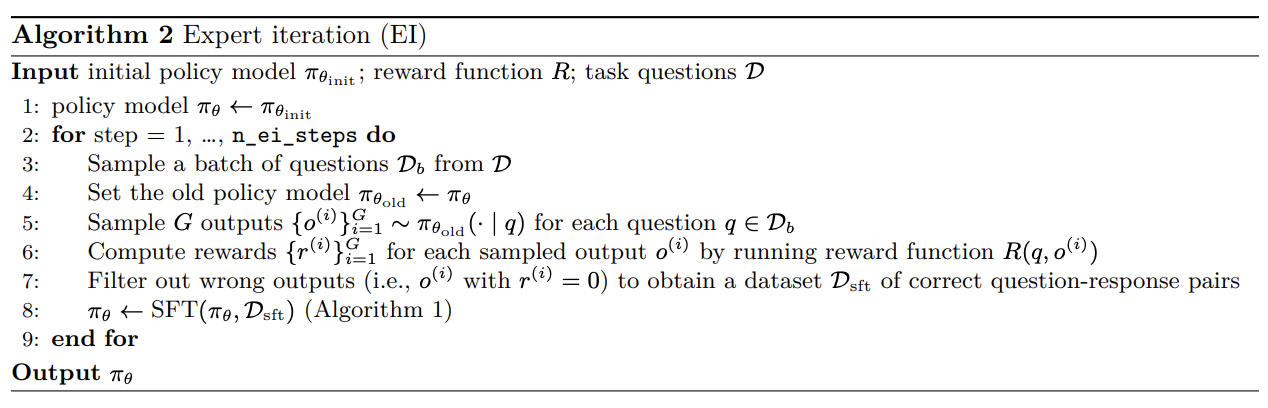
</center>

Next, we will run expert iteration on the MATH dataset.

As a tip, you should pass a min_tokens value to your vLLM SamplingParams, which will ensure that you do not generate an empty string (which could then cause a `NaN` downstream depending on your implementation). This can be done with

```python
sampling_min_tokens = 4
sampling_params = SamplingParams(temperature=sampling_temperature, max_tokens=sampling_max_tokens, 
                                 min_tokens=sampling_min_tokens, n=G, seed=seed)
```

As in SFT, you should use gradient clipping with clip value `1.0`.

#### Problem Run expert iteration on the MATH dataset

Run expert iteration on the MATH dataset (provided at `/data/a5-alignment/MATH/train.jsonl`) using the Qwen 2.5 Math 1.5B Base model, varying the number of rollouts $G$ per question and the number of epochs used in the SFT step, and using `n_ei_steps = 5`. Vary the batch size for each expert iteration step (i.e., the size of $\mathcal{D}_b$) in `{512, 1024, 2048}`. (You do not need to try all possible combinations of these hyperparameters. Just enough to draw conclusions about each is fine.) Log the entropy of the model’s reponses over training. Make sure to have vLLM terminate generations at the second answer tag `</answer>`, as done in the SFT section.

Provide the following:
- Validation accuracy curves associated with different rollout configurations. Try at least 2 different rollout counts and epoch counts.
- A model that achieves validation accuracy of at least 15% on MATH.
- A brief 2 sentence discussion comparing to your SFT performance, as well as performance across EI steps.
- A plot of the entropy of the model’s responses over training.

*Runtime Estimate:* Should take ~6 hours to run on a single H100, but this can vary a lot depending on your hardware.

## Primer on Policy Gradients

An exciting new finding in language model research is that performing RL against verified rewards with strong base models can lead to significant improvements in their reasoning capabilities and performance (*OpenAI et al., 2024, DeepSeek-AI et al., 2025*). The strongest such open reasoning models, such as DeepSeek R1 and Kimi k1.5 (*Team et al., 2025*), were trained using policy gradients, a powerful reinforcement learning algorithm that can optimize arbitrary reward functions.

We provide a brief introduction to policy gradients for RL on language models below. Our presentation is based closely on a couple great resources which walk through these concepts in more depth: OpenAI’s Spinning Up in Deep RL (*Achiam, 2018a*) and Nathan Lambert’s Reinforcement Learning from Human Feedback (RLHF) Book (*Lambert, 2024*).

### Language Models as Policies

A causal language model (LM) with parameters $\theta$ defines a probability distribution over the next token $a_t ∈ \mathcal{V}$ given the current text prefix st (the state/observation). In the context of RL, we think of the next token at as an *action* and the current text prefix $s_t$ as the *state*. Hence, the LM is a *categorical stochastic policy*

$$a_t \sim \pi_\theta(\cdot | s_t), \quad \pi_\theta(a_t | s_t) = \text{softmax} \left[f_\theta(s_t)\right]_{a_t} \ .$$

Two primitive operations will be needed in optimizing the policy with policy gradients:
1. *Sampling from the policy:* drawing an action at from the categorical distribution above,
2. *Scoring the log-likelihood of an action:* evaluating $\log \pi_\theta(a_t | s_t)$.

Generally, when doing RL with LLMs, st is the partial completion/solution produced so far, and each at is the next token of the solution; the episode ends when an end-of-text token is emitted, like `<|end_of_text|>`, or `</answer>` in the case of our `r1_zero` prompt.

### Trajectories
A (finite-horizon) trajectory is the interleaved sequence of states and actions experienced by an agent:

$$\tau = (s_0, a_0, s_1, a_1, . . . , s_T , a_T) \ ,$$

where $T$ is the length of the trajectory, i.e., $a_T$ is an end-of-text token or we have reached a maximum generation budget in tokens.

The initial state is drawn from the start distribution, $s_0 ∼ \rho_0(s_0)$, in the case of RL with LLMs, $\rho_0(s_0)$ is a distribution over formatted prompts. In general settings, state transitions follow some environment dynamics $s_{t+1} \sim P(\cdot| s_t, a_t)$. In RL with LLMs, the environment is deterministic: the next state is the old prefix concatenated with the emitted token, $s_{t+1} = s_t||a_t$. Trajectories are also called *episodes* or *rollouts*. We will use these terms interchangeably.

### Rewards and Return

A scalar reward $r_t = R(s_t, a_t)$ judges the immediate quality of the action taken at state $s_t$. For RL on verified domains, it is standard to assign zero reward to intermediate steps and a *verified reward* to the terminal action

$$
r_T = R(s_T , a_T) = \begin{cases}
1 & \text{if the trajectory } s_T || a_T \text{ matches the ground-truth according to our reward function} \ , \\
0 & \text{otherwise} \ . \\
\end{cases}
$$

The return $R(\tau)$ aggregates rewards along the trajectory. Two common choices are *finite-horizon undiscounted returns*


$$R(\tau) = \sum_{t=0}^T r_t \ ,$$

and *infinite-horizon discounted returns*

$$R(\tau) = \sum_{t=0}^\infty \gamma^t r_t \ , \ 0 < \gamma < 1 \ .$$

In our case, we will use the undiscounted formulation since episodes have a natural termination point (end-of-text or max generation length).
The objective of the agent is to maximize the expected return

$$J(θ) = \mathbb{E}_{\tau\sim\pi_\theta}\left[R(τ)\right] ,$$

leading to the optimization problem

$$\theta^∗ = \text{arg} \max_\theta J(\theta) \ .$$

###  Vanilla Policy Gradient

Next, let us attempt to learn policy parameters $\theta$ with *gradient ascent* on the expected return:

$$\theta_{k+1} = \theta_k + \alpha \nabla_\theta J(\theta_k) \ .$$

The core identity that we will use to do this is the REINFORCE policy gradient, shown below.

$$
\nabla_\theta J(\pi_\theta) = \mathbb{E}_{\tau\sim\pi_\theta} \left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) R(\tau) \right] \ .
$$

**Deriving the policy gradient:** How did we get this equation? For completeness, we will give a derivation of this identity below. We will make use of a few identities.

*Identity 1:* The probability of a trajectory is given by

$$P(\tau|\theta) = ρ_0(s_0) \prod_{t=0}^T P(s_{t+1} | s_t, a_t) \pi_\theta(a_t | s_t) \ .$$

Therefore, the log-probability of a trajectory is:

$$\log P(\tau|\theta) = \log\rho_0(s_0) + \sum_{t=0}^T \left[\log P(s_{t+1} | s_t, a_t) + \log \pi_\theta(a_t | s_t)\right] \ .$$

*Identity 2 (log-derivative trick):* $\nabla_\theta P = P \nabla_\theta \log P$.

*Identity 3:* The environment terms are constant in $\theta$, $\rho_\theta$, $P(\cdot|\cdot)$, and $R(\tau)$ do not depend on the policy parameters, so

$$\nabla_\theta \rho_0 = \nabla_\theta P = \nabla_\theta R(\tau) = 0 \ .$$

Applying the identities above, we thus have:

$$
\begin{align*}
\nabla_\theta J(\theta) 
&= \nabla_\theta \mathbb{E}_{\tau\sim\pi_\theta}[R(\tau)] \\
&= \nabla_\theta \sum_\tau P(\tau|\theta) R(\tau) \\
&= \sum_\tau \nabla_\theta P(\tau|\theta) R(\tau) \\
&= \sum_\tau P(\tau|\theta) \nabla_\theta \log P(\tau|\theta) R(\tau) \\
&= \mathbb{E}_{\tau\sim\pi_\theta} [\nabla_\theta \log P(\tau|\theta) R(\tau)] \ , \\
\end{align*}
$$

and therefore, plugging in the log-probability of a trajectory and using the fact that the environment terms are constant in $\theta$, we get the *vanilla* or REINFORCE policy gradient:

$$\nabla_\theta J(\pi_\theta)  = \mathbb{E}_{\tau\sim\pi_\theta}\left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) R(\tau)\right] \ .$$

Intuitively, this gradient will increase the log probability of every action in a trajectory that has high return, and decrease them otherwise.

**Sample estimate of the gradient:** Given a batch of $N$ rollouts $\mathcal{D} = \{\tau^{(i)}\}_{i=1}^N$ collected by sampling a starting state $s^{(i)}_0 \sim \rho_0(s_0)$ and then running the policy $\pi_\theta$ in the environment, we form an unbiased estimator of the gradient as

$$\hat g = \frac{1}{N} \sum_{i=1}^N \sum_{t=0}^T \nabla_\theta \log \pi_\theta(a^{(i)}_t | s^{(i)}_t) R(\tau^{(i)}) \ .$$

This vector is used in the gradient-ascent update $\theta \leftarrow \theta + \alpha \hat g$.

### Policy Gradient Baselines

The main issue with vanilla policy gradient is the high variance of the gradient estimate. A common technique to mitigate this is to subtract from the reward a *baseline* function $b$ that depends only on the state. This is a type of *control variate* (*Ross, 2022*): the idea is to decrease the variance of the estimator by subtracting a term that is correlated with it, without introducing bias.

Let us define the baselined policy gradient as

$$
B = \mathbb{E}_{\tau\sim\pi_\theta}\left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) \left(R(\tau) − b(s_t)\right) \right] \ .
$$

As an example, a reasonable baseline is the on-policy value function $V^π(s) = \mathbb{E}_{\tau\sim\pi_\theta} [R(\tau)|s_t = s]$, i.e. the expected return if we start at $s_t = s$ and follow the policy $\pi_\theta$ from there. Then, the quantity $R(\tau) − V^π(s_t)$ is, intuitively, how much better the realized trajectory is than expected.

As long as the baseline depends only on the state, the baselined policy gradient is unbiased. We can see this by rewriting the baselined policy gradient as

$$
B = \mathbb{E}_{\tau\sim\pi_\theta} \left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) R(\tau)\right] − \mathbb{E}_{\tau\sim\pi_\theta} \left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) b(s_t)\right] \ .
$$

Focusing on the baseline term, we see that

$$
\mathbb{E}_{\tau\sim\pi_\theta} \left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) b(s_t)\right] = 
\sum_{t=0}^T \mathbb{E}_{s_t} \bigg[b(s_t) \mathbb{E}_{a_t \sim \pi_\theta(\cdot | s_t)} \big[\nabla_\theta \log \pi_\theta(a_t|s_t)\big]\bigg] \ .
$$

In general, the expectation of the score function is zero: $\mathbb{E}_{x \sim P_\theta} [\nabla_\theta \log P_\theta(x)] = 0$. Therefore, the previous expression is zero, and

$$B = \mathbb{E}_{\tau\sim\pi_\theta} \left[\sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) R(\tau)\right] = \nabla_\theta J(\pi_\theta) \ . $$

so we conclude that the baselined policy gradient is unbiased. We will later run an experiment to see whether baselining improves downstream performance.

**A note on policy gradient losses:** When we implement policy gradient methods in a framework like PyTorch, we will define a so-called policy gradient loss `pg_loss` such that calling `pg_loss.backward()` will populate the gradient buffers of our model parameters with our approximate policy gradient $\hat g$. In math language, if we denote `pg_loss` by $L_{PG}$, we have

$$
L_{PG} = \frac{1}{N} \sum_{i=1}^N \sum_{t=0}^T \log \pi_\theta(a^{(i)}_t |s^{(i)}_t)\left(R(\tau^{(i)}) − b(s^{(i)}_t)\right) \ .
$$

Note that `pg_loss` is not a loss in the canonical sense—it’s not meaningful to report `pg_loss` on the train or validation set as an evaluation metric, and a good validation `pg_loss` doesn’t indicate that our model is generalizing well. The `pg_loss` is really just some scalar such that when we call `pg_loss.backward()`, the gradients we obtain through backprop are the approximate policy gradient $\hat g$. When doing RL, you should always log and report train and validation rewards. These are the "meaningful" evaluation metrics and what we are attempting to optimize with policy gradient methods.

### Off-Policy Policy Gradient

REINFORCE is an on-policy algorithm: the training data is collected by the same policy that we are optimizing. To see this, let us write out the REINFORCE algorithm:
1. Sample a batch of rollouts $\{\tau(i)\}_{i=1}^N$ from the current policy $\pi_\theta$.

2. Approximate the policy gradient as
$$\nabla_\theta J(\pi_\theta) \approx \hat g = \frac{1}{N} \sum_{i=1}^N \sum_{t=0}^T \nabla_\theta \log \pi_\theta(a^{(i)}_t|s^{(i)}_t) R(\tau^{(i)}) \ .$$

3. Update the policy parameters using the computed gradient: $\theta \leftarrow \theta + \alpha\hat g$.

We need to do a lot of inference to sample a new batch of rollouts, only to take just one gradient step. The behavior of an LM generally cannot change significantly in a single step, so this on-policy approach is highly inefficient.

**Off-policy policy gradient:** In off-policy learning, we instead have rollouts sampled from some policy other than the one we are optimizing. Off-policy variants of popular policy gradient algorithms like PPO and GRPO use rollouts from a previous version of the policy $\pi_{\theta_{old}}$ to optimize the current policy $\pi_\theta$. The off-policy policy gradient estimate is

$$
\hat g_{\text{off-policy}} = \frac{1}{N} \sum_{i=1}^N \sum_{t=0}^T \frac{\pi_\theta(a^{(i)}_t|s^{(i)}_t)}{\pi_{\theta_{old}}(a^{(i)}_t|s^{(i)}_t)} \nabla_\theta \log \pi_\theta(a^{(i)}_t|s^{(i)}_t) R(\tau^{(i)}) \ .
$$

This looks like an importance sampled version of the vanilla policy gradient, with reweighting terms $\pi_\theta / \pi_{\theta_{old}}$. Indeed, the above equation can be derived by importance sampling and applying an approximation that is reasonable as long as $\pi_\theta$ and $\pi_{\theta_{old}}$ are not too different. See *Degris et al. (2013)* for more on this.

## Group Relative Policy Optimization

Next, we will describe Group Relative Policy Optimization (GRPO), the variant of policy gradient that you will implement and experiment with for solving math problems.

### GRPO Algorithm

Advantage estimation. The core idea of GRPO is to sample many outputs for each question from the policy $\pi_\theta$ and use them to compute a baseline. This is convenient because we avoid the need to learn aneural value function $V_\phi(s)$, which can be hard to train and is cumbersome from the systems perspective. For a question $q$ and group outputs $\{o^{(i)}\}_{i=1}^G \sim \pi_\theta(\cdot|q)$, let $r^{(i)} = R(q, o^{(i)})$ be the reward for the $i$-th output. DeepSeekMath (*Shao et al., 2024*) and DeepSeek R1 (*DeepSeek-AI et al., 2025*) compute the group-normalized reward for the $i$-th output as

$$A^{(i)} = \frac{r^{(i)} − \text{mean}(r^{(1)}, r^{(2)}, \dots , r^{(G)})}{\text{std}(r^{(1)}, r^{(2)}, \dots , r^{(G)}) + \epsilon_{adv}} \ , $$

where $\epsilon_{adv}$ is a small constant to prevent division by zero. Note that this *advantage* $A^{(i)}$ is the same for each token in the response, i.e. $A^{(i)}_t = A^{(i)} , \ \forall t \in 1, \dots, |o^{(i)}|$, so we drop the $t$ subscript in the following.

**High-level algorithm:** Before we dive into the GRPO objective, let's first get an idea of the train loop by writing out the algorithm from *Shao et al. (2024)* in *Algorithm 3*. *Note:* This is a special case of DeepSeekMath’s GRPO with a verified reward function, no KL term, and no iterative update of the reference and reward model.

**GRPO objective:** The GRPO objective combines three ideas:
1. Compute off-policy policy gradient $\hat g_{\text{off-policy}}$ as above.
2. Computing advantages $A^{(i)}$ with group normalization as above.
3. A clipping mechanism, as in Proximal Policy Optimization (PPO, *Schulman et al. 2017*).

The purpose of clipping is to maintain stability when taking many gradient steps on a single batch of rollouts. It works by keeping the policy $\pi_\theta$ from straying too far from the old policy.

<center>
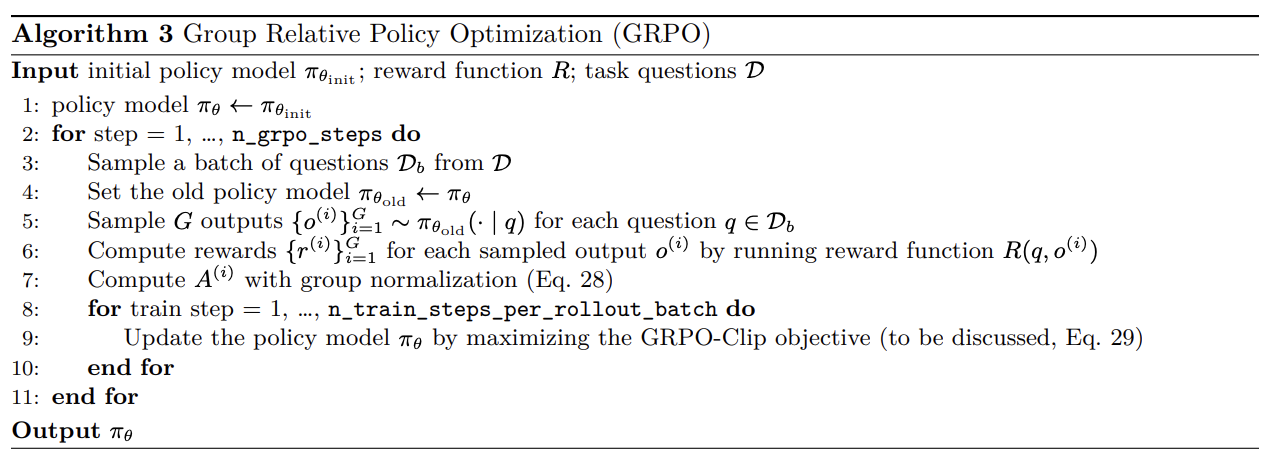
</center>

Let us first write out the full GRPO-Clip objective, and then we can build some intuition on what the clipping does:

$$
J_{\text{GRPO-Clip}}(\theta)
= \mathbb{E}_{q \sim \mathcal{D},\, \{o^{(i)}\}_{i=1}^{G} \sim \pi_{\theta}(\cdot | q)}
\left[\frac{1}{G}\sum_{i=1}^{G}\frac{1}{|o^{(i)}|}\sum_{t=1}^{|o^{(i)}|}
\min\left(
\frac{\pi_{\theta}(o_t^{(i)} | q, o_{<t}^{(i)})}{\pi_{\theta_{old}}(o_t^{(i)} | q, o_{<t}^{(i)})} A^{(i)},
\mathrm{clip}\left(
\frac{\pi_{\theta}(o_t^{(i)} | q, o_{<t}^{(i)})}{\pi_{\theta_{old}}(o_t^{(i)} | q, o_{<t}^{(i)})}, 1-\epsilon, 1+\epsilon \right) A^{(i)}
\right)\right] \ .
$$

The hyperparameter $\epsilon > 0$ controls how much the policy can change. To see this, we can rewrite the per-token objective in a more intuitive way following *Achiam (2018a,b)*. Define the function

$$
g(\epsilon, A^{(i)}) =
\begin{cases}
(1+\epsilon)A^{(i)} & \text{if } A^{(i)} \geq 0, \\
(1-\epsilon)A^{(i)} & \text{if } A^{(i)} < 0.
\end{cases}
$$

The $\min$ function inside the double sum is called the *per-token objective*. We can also rewrite the per-token objective as

$$
\text{per-token objective}
= \min\left(
\frac{\pi_{\theta}\left(o_t^{(i)} | q, o_{<t}^{(i)}\right)}{\pi_{\theta_{old}}\!\left(o_t^{(i)} | q, o_{<t}^{(i)}\right)} A^{(i)}, g(\epsilon, A^{(i)}) \right).
$$

We can now reason by cases. When the advantage $A^{(i)}$ is positive, the per-token objective simplifies to

$$
\text{per-token objective}
= \min\left(
\frac{\pi_{\theta}\left(o_t^{(i)} | q, o_{<t}^{(i)}\right)}{\pi_{\theta_{old}}\left(o_t^{(i)} | q, o_{<t}^{(i)}\right)},
1+\epsilon \right) A^{(i)}.
$$

Since $A^{(i)} > 0$, the objective goes up if the action $o_t^{(i)}$ becomes more likely under $\pi_{\theta}$, i.e., if $\pi_{\theta}(o_t^{(i)}| q,o_{<t}^{(i)})$ increases. The clipping with $\min$ limits how much the objective can increase: once $\pi_{\theta}(o_t^{(i)}|q,o_{<t}^{(i)}) > (1+\epsilon)\pi_{\theta_{old}}(o_t^{(i)}|q,o_{<t}^{(i)})$, this per-token objective hits its maximum value of $(1+\epsilon)A^{(i)}$. So, the policy $\pi_{\theta}$ is not incentivized to go very far from the old policy $\pi_{\theta_{old}}$.

Analogously, when the advantage $A^{(i)}$ is negative, the model tries to drive down $\pi_{\theta}(o_t^{(i)}|q,o_{<t}^{(i)})$, but is not incentivized to decrease it below $(1-\epsilon)\pi_{\theta_{old}}(o_t^{(i)}|q,o_{<t}^{(i)})$ (refer to *Achiam (2018)* for the full argument).

### Implementation

Now that we have a high-level understanding of the GRPO training loop and objective, we will start implementing pieces of it. Many of the pieces implemented in the SFT and EI sections will also be reused for GRPO.

Computing advantages (group-normalized rewards). First, we will implement the logic to compute advantages for each example in a rollout batch, i.e. the group-normalized rewards. We will consider two possible ways to obtain group-normalized rewards: the approach presented above, and a recent simplified approach.

Dr. GRPO (*Liu et al., 2025)* highlights that normalizing by $\text{std}(r^{(1)}, r^{(2)}, \dots, r^{(G)})$ rewards questions in a
batch with low variation in answer correctness, which may not be desirable. They propose simply removing the normalization step, computing $A^{(i)}$ instead using only the numerator,

$$A^{(i)} = r^{(i)} − \text{mean}(r^{(1)}, r^{(2)}, \dots , r^{(G)}) \ .$$

We will implement both variants and compare their performance later in the assignment.

#### Problem: Computing Group Normalized Rewards

Implement a method `compute_group_normalized_rewards` that calculates raw rewards for each rollout response, normalizes them within their groups, and returns both the normalized and raw rewards along with any metadata you think is useful. The following interface is recommended:

```python
def compute_group_normalized_rewards(reward_fn, rollout_responses, repeated_ground_truths, group_size, 
                                     advantage_eps, normalize_by_std):
    """
    Compute rewards for each group of rollout responses, normalized by the group size.
    Args:
        reward_fn: Callable[[str, str], dict[str, float]] Scores the rollout responses against the ground truths, 
            producing a dict with keys "reward", "format_reward", and "answer_reward".
        rollout_responses: list[str] Rollouts from the policy. 
            The length of this list is rollout_batch_size = n_prompts_per_rollout_batch * group_size.
        repeated_ground_truths: list[str] The ground truths for the examples. The length of this list is 
            rollout_batch_size, because the ground truth for each example is repeated group_size times.
        group_size: int Number of responses per question (group).
        advantage_eps: float Small constant to avoid division by zero in normalization.
        normalize_by_std: bool If True, divide by the per-group standard deviation; 
            otherwise subtract only the group mean.
    Returns:
        tuple[torch.Tensor, torch.Tensor, dict[str, float]].
            advantages: shape (rollout_batch_size,). Group-normalized rewards for each rollout response.
            raw_rewards: shape (rollout_batch_size,). Unnormalized rewards for each rollout response.
            metadata: your choice of other statistics to log (e.g. mean, std, max/min of rewards).
    """
```

To test your code, implement the adapter `run_compute_group_normalized_rewards`. Then, run the tests below.

In [ ]:
def run_compute_group_normalized_rewards(reward_fn, rollout_responses, repeated_ground_truths, group_size, advantage_eps, normalize_by_std):
    """
    Compute rewards for each group of rollout responses, normalized by the group size.
    For more on GRPO, see:
        DeepSeekMath: https://arxiv.org/abs/2402.03300
        DeepSeek-R1: https://arxiv.org/abs/2501.12948
    Args:
        reward_fn: Callable[[str, str], dict[str, float]]. 
            Scores the rollout responses against the ground truths, producing a dict with keys "reward", "format_reward", "answer_reward".
        rollout_responses: list[str], rollouts from the policy. 
            The length of this list is `rollout_batch_size = n_prompts_per_rollout_batch * group_size`.
        repeated_ground_truths: list[str], the ground truths for the examples. 
            The length of this list is `rollout_batch_size`, because the ground truth for each example is repeated `group_size` times.
        group_size: int, number of rollouts per group.
        advantage_eps: float, epsilon to avoid division by zero during group normalization.
        normalize_by_std: bool, whether to normalize the rewards by std(rewards).
    Returns:
        tuple[torch.Tensor, torch.Tensor, dict[str, float]]:
            torch.Tensor of shape (rollout_batch_size,): group-normalized rewards for each rollout response.
            torch.Tensor of shape (rollout_batch_size,): raw rewards for each rollout response.
            dict[str, float]: metadata for the rewards of the rollout batch.
                You may choose what you wish to log here (some statistics of the rewards, etc.).
    """
    raise NotImplementedError

In [ ]:
test_compute_group_normalized_rewards_normalize_by_std(run_compute_group_normalized_rewards)
test_compute_group_normalized_rewards_no_normalize_by_std(run_compute_group_normalized_rewards)

**Naive policy gradient loss:** Next, we will implement some methods for computing losses. As a reminder, these are not really losses in the canonical sense and should not be reported as evaluation metrics. When it comes to RL, you should instead track the train and validation returns, among other metrics (compare to the previous discussion).

We will start with the naive policy gradient loss, which simply multiplies the advantage by the log-probability of actions and then negates. With question $q$, response $o$, and response token $o_t$, the naive per-token policy gradient loss is

$$\ell_{PG} = −A_t \log p_\theta(o_t|q, o_{<t}) \ .$$

#### Problem: Compute naive policy gradient loss

Implement a method compute_naive_policy_gradient_loss that computes the per-token policy-gradient loss using raw rewards or pre-computed advantages. The following interface is recommended:

```python
def compute_naive_policy_gradient_loss(raw_rewards_or_advantages, policy_log_probs):
    """
    Compute the policy-gradient loss at every token, where raw_rewards_or_advantages is eithernthe raw reward 
    or an already-normalized advantage.
    Args:
        raw_rewards_or_advantages: torch.Tensor Shape (batch_size, 1), scalar reward/advantage for each rollout response.
        policy_log_probs: torch.Tensor Shape (batch_size, sequence_length), log probs for each token.
    Returns:
        torch.Tensor Shape (batch_size, sequence_length), the per-token policy-gradient loss 
            (to be aggregated across the batch and sequence dimensions in the training loop).
    Implementation tips:
        - Broadcast the raw_rewards_or_advantages over the sequence_length dimension.
    """
```

To test your code, implement the adapter `run_compute_naive_policy_gradient_loss`. Then run the test below.

In [ ]:
def run_compute_naive_policy_gradient_loss(raw_rewards_or_advantages, policy_log_probs):
    """
    Compute policy gradient loss using either raw rewards or advantages.
    Args:
        raw_rewards_or_advantages: torch.Tensor of shape (batch_size, 1): the raw rewards or advantages for each rollout response.
        policy_log_probs: torch.Tensor of shape (batch_size, sequence_length): the log-probs of the policy.
    Returns:
        torch.Tensor of shape (batch_size, sequence_length): the policy gradient per-token loss.
    """
    raise NotImplementedError

In [ ]:
test_compute_naive_policy_gradient_loss(run_compute_naive_policy_gradient_loss)

**GRPO-Clip loss:** Next, we will implement the more interesting GRPO-Clip loss. The per-token GRPO-Clip loss is the negated per-token objective

$$
\ell_{PG} = -\min\left[
\frac{\pi_{\theta}(o_t^{(i)} | q, o_{<t}^{(i)})}{\pi_{\theta_{old}}(o_t^{(i)} | q, o_{<t}^{(i)})} A^{(i)},
\mathrm{clip}\left(
\frac{\pi_{\theta}(o_t^{(i)} | q, o_{<t}^{(i)})}{\pi_{\theta_{old}}(o_t^{(i)} | q, o_{<t}^{(i)})}, 1-\epsilon, 1+\epsilon \right) A^{(i)}
\right] \ .
$$

#### Problem: Compute GRPO-Clip loss

Implement a method compute_grpo_clip_loss that computes the per-token GRPO-Clip loss. The following interface is recommended:

```python
def compute_grpo_clip_loss(advantages, policy_log_probs, old_log_probs, cliprange):
    """
    Args:
        advantages: torch.Tensor Shape (batch_size, 1), per-example advantages A.
        policy_log_probs: torch.Tensor Shape (batch_size, sequence_length), per-token log probs from the policy 
            being trained.
        old_log_probs: torch.Tensor Shape (batch_size, sequence_length), per-token log probs from the old policy.
        cliprange: float Clip parameter ϵ (e.g. 0.2).
    Returns:
        tuple[torch.Tensor, dict[str, torch.Tensor]].
            loss: torch.Tensor of shape (batch_size, sequence_length), the per-token clipped loss.
            metadata: dict containing whatever you want to log. We suggest logging whether each token was clipped or not, 
                i.e. whether the clipped policy gradient loss on the RHS of the min was lower than the LHS.
    Implementation tips:
        - Broadcast advantages over sequence_length.
    """
```

To test your code, implement the adapter `run_compute_grpo_clip_loss`. Then run the tests below.

In [ ]:
def run_compute_grpo_clip_loss(advantages, policy_log_probs, old_log_probs, cliprange):
    """
    Compute the GRPO-Clip loss.
    Args:
        advantages: torch.Tensor of shape (batch_size, 1): the advantages for each rollout response.
        policy_log_probs: torch.Tensor of shape (batch_size, sequence_length): the log-probs of the policy.
        old_log_probs: torch.Tensor of shape (batch_size, sequence_length): the log-probs of the old policy.
        cliprange: float: the clip range for the ratio.
    Returns:
        tuple[torch.Tensor, dict[str, torch.Tensor]]:
            torch.Tensor of shape (batch_size, sequence_length): the GRPO-Clip per-token loss.
            dict[str, torch.Tensor]: metadata for the GRPO-Clip loss (used to compute clip fraction).
    """
    raise NotImplementedError

In [ ]:
test_compute_grpo_clip_loss_large_cliprange(run_compute_grpo_clip_loss)
test_compute_grpo_clip_loss_small_cliprange(run_compute_grpo_clip_loss)

**Policy gradient loss wrapper:** We will be running ablations comparing three different versions of policy gradient:
1. `no_baseline`: Naive policy gradient loss without a baseline, i.e. advantage is just the raw rewards $A = R(q, o)$.
2. `reinforce_with_baseline`: Naive policy gradient loss but using our group-normalized rewards as the advantage. If $\bar r$ are the group-normalized rewards from `compute_group_normalized_rewards` (which may or may not be normalized by the group standard deviation), then $A = \bar r$.
3. `grpo_clip`: GRPO-Clip loss.

For convenience, we will implement a wrapper that lets us easily swap between these three policy gradient losses.

#### Problem: Compute policy-gradient wrapper

Implement compute_policy_gradient_loss, a convenience wrapper that dispatches to the correct loss routine (no_baseline, reinforce_with_baseline, or grpo_clip) and returns both the per-token loss and any auxiliary statistics. The following interface is recommended:

```python
def compute_policy_gradient_loss(policy_log_probs, loss_type, raw_rewards=None, advantages=None, 
                                 old_log_probs=None, cliprange=None):
    """
    Select and compute the desired policy-gradient loss.
    Args:
        policy_log_probs: (batch_size, sequence_length), per-token log-probabilities from the policy being trained.
        loss_type: One of "no_baseline", "reinforce_with_baseline", or "grpo_clip".
        raw_rewards: Required if loss_type == "no_baseline"; shape (batch_size, 1).
        advantages: Required for "reinforce_with_baseline" and "grpo_clip"; shape (batch_size, 1).
        old_log_probs: Required for "grpo_clip"; shape (batch_size, sequence_length).
        cliprange: Required for "grpo_clip"; scalar ϵ used for clipping.
    Returns:
        tuple[torch.Tensor, dict[str, torch.Tensor]].
            loss: (batch_size, sequence_length), per-token loss.
            metadata: dict, statistics from the underlying routine (e.g., clip fraction for GRPO-Clip).
    Implementation tips:
        - Delegate to compute_naive_policy_gradient_loss or compute_grpo_clip_loss.
        - Perform argument checks (see assertion pattern above).
        - Aggregate any returned metadata into a single dict.
    """
```

To test your code, implement the adapter `run_compute_policy_gradient_loss`. Then run the tests below.

In [ ]:
def run_compute_policy_gradient_loss(policy_log_probs, loss_type, raw_rewards, advantages, old_log_probs, cliprange):
    """
    Wrapper that delegates to the appropriate policy gradient loss function above.
    """
    raise NotImplementedError

In [ ]:
test_compute_policy_gradient_loss_no_baseline(run_compute_policy_gradient_loss)
test_compute_policy_gradient_loss_reinforce_with_baseline(run_compute_policy_gradient_loss)
test_compute_policy_gradient_loss_grpo_clip(run_compute_policy_gradient_loss)

**Masked mean:** Up to this point, we have the logic needed to compute advantages, log probabilities, pertoken losses, and helpful statistics like per-token entropies and clip fractions. To reduce our per-token loss tensors of shape `(batch_size, sequence_length)` to a vector of losses (one scalar for each example), we will compute the mean of the loss over the sequence dimension, but only over the indices corresponding to the response (i.e. the token positions for which `mask[i, j]==1`).

Normalizing by the sequence length has been canonical in most codebases for doing RL with LLMs, but it is not obvious that this is the right thing to do—you may notice, looking at our statement of the policy gradient estimate above, that there is no normalization factor $1/T^{(i)}$. We will start with this standard primitive, often referred to as a `masked_mean`, but will later test out using the masked_normalize method that we implemented during SFT.

We will allow specification of the dimension over which we compute the mean, and if `dim` is `None`, we will compute the mean over all masked elements. This may be useful to obtain average per-token entropies on the response tokens, clip fractions, etc.

#### Problem: Masked mean

Implement a method masked_mean that averages tensor elements while respecting a boolean mask. The following interface is recommended:

```python
def masked_mean(tensor, mask, dim=None):
    """
    Compute the mean of tensor along a given dimension, considering only those elements where mask == 1.
    Args:
        tensor: torch.Tensor The data to be averaged.
        mask: torch.Tensor Same shape as tensor; positions with 1 are included in the mean.
        dim: int | None Dimension over which to average. If None, compute the mean over all masked elements.
    Returns:
        torch.Tensor The masked mean; shape matches tensor.mean(dim) semantics.
    """
```

To test your code, implement the adapter `run_masked_mean`. Then run the tests below.

In [ ]:
def run_masked_mean(tensor, mask, dim=None):
    """
    Compute the mean of the tensor along a dimension, considering only the elements with mask value 1.
    Args:
        tensor: torch.Tensor, the tensor to compute the mean of.
        mask: torch.Tensor, the mask. We only take the mean over the elements with mask value 1.
        dim: int | None, the dimension to compute the mean along.
            If None, sum over all non-masked elements and average by their total count.
    Returns:
        torch.Tensor, the mean of the tensor along the specified dimension, considering only the elements with mask value 1.
    """
    raise NotImplementedError

In [ ]:
test_masked_mean_dim_0(run_masked_mean)
test_masked_mean_dim_1(run_masked_mean)
test_masked_mean_dim_last(run_masked_mean)
test_masked_mean_dim_none(run_masked_mean)

**GRPO microbatch train step:** Now we are ready to implement a single microbatch train step for GRPO (recall that for a train mini-batch, we iterate over many micro-batches if `gradient_accumulation_steps > 1`).

Specifically, given the raw rewards or advantages and log probs, we will compute the per-token loss, use `masked_mean` to aggregate to a scalar loss per example, average over the batch dimension, adjust for gradient accumulation, and backpropagate.

#### Problem: GRPO micro-batch training step

Implement a single micro-batch update for GRPO, including policy-gradient loss, averaging with a mask, and gradient scaling. The following interface is recommended:

```python
def grpo_microbatch_train_step(policy_log_probs, response_mask, gradient_accumulation_steps, loss_type, raw_rewards=None, 
                               advantages=None, old_log_probs=None, cliprange=None):
    """
    Execute a forward-and-backward pass on a microbatch.
    Args:
        policy_log_probs: (batch_size, sequence_length), per-token log-probabilities from the policy being trained.
        response_mask: (batch_size, sequence_length), 1 for response tokens, 0 for prompt/padding.
        gradient_accumulation_steps: Number of microbatches per optimizer step.
        loss_type: One of "no_baseline", "reinforce_with_baseline", "grpo_clip".
        raw_rewards: Needed when loss_type == "no_baseline"; shape (batch_size, 1).
        advantages: Needed when loss_type != "no_baseline"; shape (batch_size, 1).
        old_log_probs: Required for GRPO-Clip; shape (batch_size, sequence_length).
        cliprange: Clip parameter ϵ for GRPO-Clip.
    Returns:
        tuple[torch.Tensor, dict[str, torch.Tensor]].
            loss: scalar tensor. The microbatch loss, adjusted for gradient accumulation. We return this 
                so we can log it.
            metadata: Dict with metadata from the underlying loss call, and any other statistics you might want to log.
    Implementation tips:
        - You should call loss.backward() in this function. Make sure to adjust for gradient accumulation.
    """
```

To test your code, implement the adapter `run_grpo_microbatch_train_step`. Then run the tests below.

In [ ]:
def run_grpo_microbatch_train_step(policy_log_probs, response_mask, gradient_accumulation_steps, loss_type, raw_rewards=None, advantages=None,
                                   old_log_probs=None, cliprange=None):
    """
    Compute the policy gradient loss and backprop its gradients for a microbatch.
    Args:
        policy_log_probs: torch.Tensor of shape (batch_size, sequence_length): the log-probs of the policy.
        response_mask: torch.Tensor of shape (batch_size, sequence_length): the mask for the response.
        gradient_accumulation_steps: int, the number of gradient accumulation steps.
        loss_type: Literal["no_baseline", "reinforce_with_baseline", "grpo_clip"], the type of loss function to use.
        raw_rewards: torch.Tensor | None, the raw rewards for each rollout response. Needed for loss_type="no_baseline".
        advantages: torch.Tensor | None, advantages for each rollout response. Needed for loss_type in {"reinforce_with_baseline", "grpo_clip"}.
        old_log_probs: torch.Tensor | None, the log-probs of the old policy. Needed for loss_type="grpo_clip".
        cliprange: float | None, the clip range for the ratio. Needed for loss_type="grpo_clip".
        constant_normalize_factor: int | None, provided if we want to sum over the sequence dimension and normalize by this 
            constant factor (as in Dr. GRPO).
    Returns:
        tuple[torch.Tensor, dict[str, torch.Tensor]]: the policy gradient loss and its metadata.
    """
    raise NotImplementedError

In [ ]:
test_grpo_microbatch_train_step_grpo_clip(run_grpo_microbatch_train_step)
test_grpo_microbatch_train_step_grpo_clip_10_steps(run_grpo_microbatch_train_step)

**Putting it all together – GRPO train loop:** Now we will put together a complete train loop for GRPO. You should refer to *Algorithm 1* above for the overall structure, using the methods we’ve implemented where appropriate. 

Below we provide some starter hyperparameters. If you have a correct implementation, you should see reasonable results with these.

```python
n_grpo_steps = 200
learning_rate = 1e-5
advantage_eps = 1e-6
rollout_batch_size = 256
group_size = 8
sampling_temperature = 1.0
sampling_min_tokens = 4 # As in Expiter, disallow empty string responses
sampling_max_tokens = 1024
epochs_per_rollout_batch = 1 # On-policy
train_batch_size = 256 # On-policy
gradient_accumulation_steps = 128 # microbatch size is 2, will fit on H100
gpu_memory_utilization = 0.85
loss_type = 'reinforce_with_baseline'
use_std_normalization = True
optimizer = torch.optim.AdamW(policy.parameters(), lr=learning_rate, weight_decay=0.0, betas=(0.9, 0.95))
```
These default hyperparameters will start you in the on-policy setting—for each rollout batch, we take a single gradient step. In terms of hyperparameters, this means that `train_batch_size` is equal to `rollout_batch_size`, and `epochs_per_rollout_batch` is equal to 1.

Here are some sanity check asserts and constants that should remove some edge cases and point you in the right direction:

```python
assert train_batch_size % gradient_accumulation_steps == 0, 'train_batch_size must be divisible by gradient_accumulation_steps'
micro_train_batch_size = train_batch_size // gradient_accumulation_steps
assert rollout_batch_size % group_size == 0, 'rollout_batch_size must be divisible by group_size'
n_prompts_per_rollout_batch = rollout_batch_size // group_size
assert train_batch_size >= group_size, 'train_batch_size must be greater than or equal to group_size'
n_microbatches_per_rollout_batch = rollout_batch_size // micro_train_batch_size
```

And here are a few additional tips:
- Remember to use the `r1_zero prompt`, and direct vLLM to stop generation at the second answer tag `</answer>`, as in the previous experiments.
- We suggest using `typer` for argument parsing.
- Use gradient clipping with clip value `1.0`.
- You should routinely log validation rewards (e.g., every 5 or 10 steps). You should evaluate on at least 1024 validation examples to compare hyperparameters, as CoT/RL evaluations can be noisy.
- With our implementation of the losses, GRPO-Clip should only be used when off-policy (since it requires the old log-probabilities).
- In the off-policy setting with multiple epochs of gradient updates per rollout batch, it would be wasteful to recompute the old log-probabilities for each epoch. Instead, we can compute the old log-probabilities once and reuse them for each epoch.
- You should not differentiate with respect to the old log-probabilities.
- You should log some or all of the following for each optimizer update:
    - The loss.
    - Gradient norm.
    - Token entropy.
    - Clip fraction, if off-policy.
    - Train rewards (total, format, and answer).
    - Anything else you think could be useful for debugging.

#### Problem: GRPO training loop

Implement a complete train loop for GRPO. Begin training a policy on MATH and confirm that you see validation rewards improving, along with sensible rollouts over time. Provide a plot with the validation rewards with respect to steps, and a few example rollouts over time.

## GRPO Experiments

Now we can start experimenting with our GRPO train loop, trying out different hyperparameters and algorithm tweaks. Each experiment will take 2 GPUs, one for the vLLM instance and one for the policy.

*Note on stopping runs early:* if you see significant differences between hyperparameters before 200 GRPO steps (e.g., a config diverges or is clearly suboptimal), you should of course feel free to stop the experiment early, saving time and compute for later runs. The GPU hours mentioned below are a rough estimate.

#### Problem: Tune the learning rate
Starting with the suggested hyperparameters above, perform a sweep over the learning rates and report the final validation answer rewards (or note divergence if the optimizer diverges). Provide the following:
- Validation reward curves associated with multiple learning rates.
- A model that achieves validation accuracy of at least 25% on MATH.
- A brief discussion on any other trends you notice on other logged metrics.

*Runtime Estimate:* Should take ~6 hours to run on a single H100, but this can vary a lot depending on your hardware.

For the rest of the experiments, you can use the learning rate that performed best in your sweep above.

*Effect of baselines:* Continuing on with the hyperparameters above (except with your tuned learning rate), we will now investigate the effect of baselining. We are in the on-policy setting, so we will compare the loss types:
- `no_baseline`
- `reinforce_with_baseline`

Note that `use_std_normalization` is `True` in the default hyperparameters.

#### Problem: Effect of baselining GRPO

Train a policy with reinforce_with_baseline and with no_baseline. Provide the following:
- Validation reward curves associated with each loss type.
- A brief discussion on any other trends you notice on other logged metrics.

*Runtime Estimate:* Should take ~2 hours to run on a single H100, but this can vary a lot depending on your hardware.

For the next few experiments, you should use the best loss type found in the above experiment.

*Length normalization:* As hinted at when we were implementing `masked_mean`, it is not necessary or even correct to average losses over the sequence length. The choice of how to sum over the loss is an important hyperparameter which results in different types of credit attribution to policy actions.

Let us walk through an example from *Lambert (2024)* to illustrate this. Inspecting the GRPO train step, we start out by obtaining per-token policy gradient losses (ignoring clipping for a moment):

```python
advantages # (batch_size, 1)
per_token_probability_ratios # (batch_size, sequence_length)
per_token_loss = -advantages * per_token_probability_ratios
```

where we have broadcasted the advantages over the sequence length. Let’s compare two approaches to
aggregating these per-token losses:
- The masked_mean we implemented, which averages over the unmasked tokens in each sequence.
- Summing over the unmasked tokens in each sequence, and dividing by a constant scalar (which our `masked_normalize` method supports with `constant_normalizer != 1.0`) (*Liu et al., 2025, Yu et al., 2025*).

We will consider an example where we have a batch size of 2, the first response has 4 tokens, and the second response has 7 tokens. Then, we can see how these normalization approaches affect the gradient.

```python
from your_utils import masked_mean, masked_normalize

ratio = torch.tensor([
    [1, 1, 1, 1, 1, 1, 1,],
    [1, 1, 1, 1, 1, 1, 1,]], requires_grad=True)
advs = torch.tensor([
    [2, 2, 2, 2, 2, 2, 2,],
    [2, 2, 2, 2, 2, 2, 2,]])
masks = torch.tensor([
    [1, 1, 1, 1, 0, 0, 0,],  # generation 1: 4 tokens
    [1, 1, 1, 1, 1, 1, 1,]]) # generation 2: 7 tokens
# Normalize with each approach
max_gen_len = 7
masked_mean_result = masked_mean(ratio * advs, masks, dim=1)
masked_normalize_result = masked_normalize(ratio * advs, masks, dim=1, constant_normalizer=max_gen_len)
print('masked_mean', masked_mean_result)
print('masked_normalize', masked_normalize_result)
# masked_mean tensor([2., 2.], grad_fn=<DivBackward0>)
# masked_normalize tensor([1.1429, 2.0000], grad_fn=<DivBackward0>)
masked_mean_result.mean().backward()
print('ratio.grad', ratio.grad)
# ratio.grad:
# tensor([[0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000],
# [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429]])
ratio.grad.zero_()
masked_normalize_result.mean().backward()
print('ratio.grad', ratio.grad)
# ratio.grad:
# tensor([
#    [0.1429, 0.1429, 0.1429, 0.1429, 0.0000, 0.0000, 0.0000],
#    [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429]])
```

#### Problem:  Think about length normalization

Compare the two approaches (without running experiments yet). What are the pros and cons of each approach? Are there any specific settings or examples where one approach seems better?

Now, let’s compare masked_mean with masked_normalize empirically.

#### Problem: Effect of GRPO length normalization

Compare normalization with masked_mean and masked_normalize with an end-toend GRPO training run. Report the validation answer reward curves. Comment on the findings, including any other metrics that have a noticeable trend. *Hint:* consider metrics related to stability, such as the gradient norm.

*Runtime Estimate:* Should take ~2 hours to run on a single H100, but this can vary a lot depending on your hardware.

Fix to the better performing length normalization approach for the following experiments.

*Normalization with group standard deviation:* Recall our standard implementation of `compute_group_normalized_rewards` (based on *Shao et al. (2024)*, *DeepSeek-AI et al. (2025)*), where we normalized by the group standard deviation. *Liu et al. (2025)* notes that dividing by the group standard deviation could introduce unwanted biases to the training procedure: questions with lower standard deviations (e.g., too easy or too hard questions with all rewards almost all 1 or all 0) would receive higher weights during training. 

*Liu et al. (2025)* propose removing the normalization by the standard deviation, which we have already implemented in `compute_group_normalized_rewards` and will now test.

#### Problem: Effect of GRPO standard deviation normalization

Compare the performance of `use_std_normalization == True` and `use_std_normalization == False`. Report the validation answer reward curves. Comment on the findings, including any other metrics that have a noticeable trend. *Hint:* consider metrics related to stability, such as the gradient norm.

*Runtime Estimate:* Should take ~2 hours to run on a single H100, but this can vary a lot depending on your hardware.

Fix to the better performing group normalization approach for the following experiments.

*Off-policy versus on-policy:* The hyperparameters we have experimented with so far are all on-policy: we take only a single gradient step per rollout batch, and therefore we are almost exactly using the "principled" approximation $\hat g$ to the policy gradient (besides the length and advantage normalization choices mentioned above).

While this approach is theoretically justified and stable, it is inefficient. Rollouts require slow generation from the policy and therefore are the dominating cost of GRPO; it seems wasteful to only take a single gradient step per rollout batch, which may be insufficient to meaningfully change the policy’s behavior.

We will now experiment with off-policy training, where we take multiple gradient steps (and even multiple epochs) per rollout batch.

#### Problem: Implement off-policy GRPO

Implement off-policy GRPO training. Depending on your implementation of the full GRPO train loop above, you may already have the
infrastructure to do this. If not, you need to implement the following:
- You should be able to take multiple epochs of gradient steps per rollout batch, where the number of epochs and optimizer updates per rollout batch are controlled by `rollout_batch_size`, `epochs_per_rollout_batch`, and `train_batch_size`.
- Edit your main training loop to get response log-probs from the policy after each rollout batch generation phase and before the inner loop of gradient steps—these will be the `old_log_probs`. We suggest using `torch.inference_mode()`.
- You should use the "GRPO-Clip" loss type.

Now we can use the number of epochs and optimizer updates per rollout batch to control the extent to which we are off-policy.

#### Problem: Off-policy GRPO hyperparameter sweep

Fixing `rollout_batch_size = 256`, choose a range over `epochs_per_rollout_batch` and `train_batch_size` to sweep over. First do a broad sweep for a limited number of GRPO steps (<50) to get a sense of the performance landscape, and then a more focused sweep for a larger
number of GRPO steps (200). Provide a brief experiment log explaining the ranges you chose.

Compare to your on-policy run with `epochs_per_rollout_batch = 1` and `train_batch_size = 256`, reporting plots with respect to number of validation steps as well as with respect to wall-clock time.

Report the validation answer reward curves. Comment on the findings, including any other metrics that have a noticeable trend such as entropy and response length. Compare the entropy of the model's responses over training to what you observed in the EI experiment.

*Hint:* You will need to change gradient_accumulation_steps to keep memory usage constant.

*Runtime Estimate:* Should take ~12 hours to run on a single H100, but this can vary a lot depending on your hardware.

*Ablating clipping in the off-policy setting:* Recall that the purpose of clipping in GRPO-Clip is to prevent the policy from moving too far away from the old policy when taking many gradient steps on a single rollout batch. Next, we will ablate clipping in the off-policy setting to test to what extent it is actually necessary. In other words, we will use per-token loss

$$\ell_{PG} = -\frac{\pi_{\theta}(o_t | q, o_{<t})}{\pi_{\theta_{old}}(o_t | q, o_{<t})} A_t \ .$$

#### Problem: Off-policy GRPO-Clip ablation

Implement the unclipped per-token loss as a new loss type `"GRPO-No-Clip"`. Take your best performing off-policy hyperparameters from the previous problem and run the unclipped version of the loss. Report the validation answer reward curves. Comment on the findings compared to your GRPO-Clip run, including any other metrics that have a noticeable trend such as entropy, response length, and gradient norm.

*Runtime Estimate:* Should take ~2 hours to run on a single H100, but this can vary a lot depending on your hardware.

*Effect of prompt:* As a last ablation, we'll investigate a surprising phenomenon: the prompt used during RL can have a dramatic effect on the performance of the model, depending on how the model was pretrained.

Instead of using the R1-Zero prompt at `cs336_alignment/prompts/r1_zero.prompt`, we will instead use an extremely simple prompt at `cs336_alignment/prompts/question_only.prompt: {question}`.

You will use this prompt for both training and validation, and will change your reward function (used both in training and validation) to the `question_only_reward_fn` located in `cs336_alignment/drgrpo_grader.py`.

#### Problem: Prompt ablation

Report the validation answer reward curves for both the R1-Zero prompt and the question-only prompt. How do metrics compare, including any other metrics that have a noticeable trend such as entropy, response length, and gradient norm? Try to explain your findings.

*Runtime Estimate:* Should take ~2 hours to run on a single H100, but this can vary a lot depending on your hardware.

# Leaderboard: GRPO on MATH

As the last part of the (mandatory) assignment, you will experiment with approaches to obtain the highest validation rewards possible within 4 hours of training on 2 H100 GPUs.

*Model:* We will continue using the Qwen 2.5 Math 1.5B Base model.

*Dataset:* We will continue using the MATH train and validation dataset available on the cluster at `/data/a5-alignment/MATH/train.jsonl` and `/data/a5-alignment/MATH/validation.jsonl`. You are not allowed to use any other data or do SFT on reasoning chains from stronger models, etc. You must report validation accuracy on the entire validation set (all 5K examples), using the sampling hyperparameters given above (temperature `1.0`, max tokens `1024`). You are allowed to filter the train set, or design a curriculum over the data, as you desire. You must use the R1-Zero prompt for validation, and during validation, you must use exactly the `r1_zero_reward_fn` reward function provided in the starter code (you are allowed to develop another reward function for use during training if you wish).

*Algorithm:* You are free to tune hyperparameters or change the training algorithm entirely, as long as you do not use any extraneous data or another model (you are free to use more copies of the model if you want).

*Systems optimizations:* You might observe that in our simple GRPO implementation above, at least one GPU is always idle. You will likely find notable improvements by improving the systems characteristics of our pipeline. For example, you might consider lower precision for rollouts or training, torch.compile, and other systems optimizations. You are definitely not constrained to placing vLLM on a single device and the train policy on another device, and are encouraged to think of better ways to parallelize.

*Ideas:* For some ideas on possible improvements, see the following repos: veRL, trl, torchtune, oat.

*On KL divergence:* We also note that in the above experiments, we did not include a KL divergence term with respect to some reference model (usually this is a frozen SFT or pretrained checkpoint). In our experiments and others from the literature (*Liu et al., 2025, NTT123, 2025*), we found that omitting the KL term had no impact on performance while saving GPU memory (no need to store a reference model). However, many GRPO repos include it by default and you are encouraged to experiment with KL or other forms of regularization, *as long as you use Qwen 2.5 Math 1.5B Base or some model obtained through your algorithm for it*.

#### Problem: Leaderboard

Report a validation accuracy obtained within 4 hours of training on 2 H100 GPUs and a screenshot of your validation accuracy with respect to wall-clock time, where the x-axis ends at $\leq 4$ hours. As a reminder, we place the following constraints on your evaluation:
1. Your validation accuracy should be the average accuracy over the entire MATH validation set (all 5K examples).
2. You must use the R1-Zero prompt at validation time.
3. You must use temperature `1.0` and max tokens `1024` with vLLM for evaluation.
4. You must calculate validation accuracy by averaging the answer rewards produced by the `r1_zero_reward_fn` reward function provided in the starter code.

*Runtime Estimate:* Should take ~16 hours to run on a single H100, but this can vary a lot depending on your hardware.